In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

movies_df = pd.read_csv("Datasets/clean_movies.csv")
cast_df = pd.read_csv("Datasets/clean_cast.csv")
crew_df = pd.read_csv("Datasets/clean_crew.csv")
keyword_df = pd.read_csv("Datasets/clean_keyword.csv")
genres_df = pd.read_csv("Datasets/clean_genres.csv")
production_df = pd.read_csv("Datasets/clean_production.csv")



In [254]:
#inspect the cleaned data

data_frames = {
    "movies_df": movies_df,
    "cast_df": cast_df,
    "crew_df": crew_df,
    "keyword_df": keyword_df,
    "genres_df": genres_df,
    "production_df": production_df
}

for name, df in data_frames.items():
    print(f"\n" + "*"*55)
    print(f" {name} Head")
    print("*"*55)
    print(df.head())
    
    print(f"\n" + "*"*55)
    print(f" {name} Info")
    print("*"*55)
    df.info()
    print("*"*55)



*******************************************************
 movies_df Head
*******************************************************
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toysto

In [255]:
#create derived value -> profit

movies_df['profit'] = movies_df['revenue'] - movies_df['budget']
# profit_avg = movies_df['profit'].mean().round(2)
# pop_avg = movies_df['popularity'].mean()

# print(f"The average profit from this collection is ${profit_avg}")
# print(f"The average popularity from this collection is {pop_avg}")

# under_movies_df = movies_df[(movies_df['profit'] < profit_avg) & (movies_df['popularity'] < pop_avg)]


In [256]:
#What constitutes a flop or a low performing film?

#Is it popularity?  

#Drop any row with popularity = 0 and with vote counts less than 15.  This will eliminate blanks and films with low vote counts.

movies_df = movies_df[(movies_df['popularity'] != 0)& (movies_df['vote_count'] > 15)]

#List the top 100 least popular movies

least_popular = movies_df.sort_values('popularity').head(100)

least_popular[['original_title', 'popularity']]

,original_title,popularity
13559,Land des Schweigens und der Dunkelheit,0.000220
34233,Elephant,0.000578
9942,Parenti serpenti,0.000844
11570,7 Plus Seven,0.001021
41170,Eccezzziunale... veramente,0.002538
...,...,...
16822,Nijushi no hitomi,0.617717
15587,अमर अकबर एन्थोनी,0.618416
25302,Nativity 2: Danger in the Manger!,0.619534
18754,Like Water,0.621056


In [257]:
#From this top 100 list what are the agreed upon least popular films?
#i am not going to use this anymore.  especially since i just realized that popularity and user rating are different :(

# most_unpop = least_popular.sort_values(by=['popularity', 'vote_count'],ascending=[True, False]).head(100)

# most_unpop[['original_title', 'popularity', 'vote_count']]

In [258]:
#low user rating
movies_df = movies_df[(movies_df['vote_average'] != 0)& (movies_df['vote_count'] > 50)]

#List the top 100 lowest rated movies

low_rating = movies_df.sort_values('vote_average').head(100)

low_rating[['original_title', 'vote_average']]

,original_title,vote_average
8620,Manos: The Hands of Fate,2.0
17745,Birdemic: Shock and Terror,2.1
6734,House of the Dead,2.8
40563,Back in the Day,2.8
30816,The Hottie & The Nottie,2.9
...,...,...
36454,The Abandoned,4.1
14784,Stan Helsing,4.1
36646,Norm of the North,4.1
1490,Speed 2: Cruise Control,4.1


In [259]:
#Is a flop a film that lost money?

#drop any film with budget or revenue equal to 0 to eliminate noise

movies_df = movies_df[(movies_df['budget'] > 500) & (movies_df['revenue'] > 500)]
movies_df.sort_values('revenue').head(100)



,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,keywords,movie_text,profit
23184,False,NaN,1500000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,138222,tt1885300,en,Best Man Down,A newlywed couple cancels their honeymoon and ...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Best Man Down,False,6.1,65.0,[],comedy drama a newlywed couple cancels their h...,-1498062.0
20252,False,NaN,12000000,"[{'id': 53, 'name': 'Thriller'}]",http://www.thesamaritanfilm.com/,98339,tt1867093,en,The Samaritan,"After twenty years in prison, Foley is finishe...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,The Samaritan,False,5.2,69.0,"[{'id': 378, 'name': 'prison'}, {'id': 572, 'n...",thriller prison sex revenge incest grifter pat...,-11997479.0
20935,False,NaN,2500000,"[{'id': 18, 'name': 'Drama'}]",NaN,94901,tt1945062,en,About Cherry,A drama centered on a troubled young woman who...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,There's No Such Thing As Going Too Far.,About Cherry,False,4.4,91.0,"[{'id': 445, 'name': 'pornography'}]",drama there s no such thing as going too far. ...,-2496997.0
19381,False,NaN,3000000,"[{'id': 27, 'name': 'Horror'}, {'id': 53, 'nam...",NaN,89691,tt1603257,en,ATM,"On a late night visit to an ATM, three co-work...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,No warning. No control. No escape.,ATM,False,5.1,195.0,"[{'id': 157145, 'name': 'atm'}, {'id': 157146,...",horror thriller no warning. no control. no esc...,-2996990.0
44216,False,NaN,10500000,"[{'id': 18, 'name': 'Drama'}, {'id': 53, 'name...",NaN,390051,tt4581576,en,Aftermath,A fatal plane crash changes the lives of Roman...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,All he had left was revenge,Aftermath,False,5.8,162.0,"[{'id': 822, 'name': 'airport'}, {'id': 894, '...",drama thriller all he had left was revenge air...,-10496549.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23618,False,NaN,4141459,"[{'id': 18, 'name': 'Drama'}]",http://diaphana.fr/film/17-filles,87368,tt1860152,fr,17 filles,Inspired by events that took place in Massachu...,...,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,17 Girls,False,5.6,103.0,"[{'id': 187056, 'name': 'woman director'}]",drama woman director inspired by events that t...,-3939852.0
16949,False,NaN,12000000,"[{'id': 80, 'name': 'Crime'}, {'id': 35, 'name...",NaN,53172,tt1220888,en,Henry's Crime,An aimless man is sent to prison for a crime h...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The real crime is not committing to your dreams.,Henry's Crime,False,5.8,110.0,"[{'id': 5569, 'name': 'vomit'}, {'id': 10960, ...",crime comedy the real crime is not committing ...,-11795060.0
8952,False,NaN,2500000,"[{'id': 35, 'name': 'Comedy'}, {'id': 27, 'nam...",NaN,27274,tt0099611,en,Frankenhooker,A medical school dropout loses his fiancée in ...,...,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A terrifying tale of sluts and bolts.,Frankenhooker,False,5.7,65.0,"[{'id': 293, 'name': 'female nudity'}, {'id': ...",comedy horror science fiction a terrifying tal...,-2294932.0
10820,False,NaN,4750000,"[{'id': 14, 'name': 'Fantasy'}, {'id': 27, 'na...",http://www.tamaramovie.com/,10263,tt0401815,en,Tamara,"Tamara, an unattractive girl who is picked on ...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Revenge has a killer body.,Tamara,False,5.1,64.0,"[{'id': 3133, 'name': 'vampire'}, {'id': 3737,...",fantasy horror thriller revenge has a killer b...,-4543129.0


In [280]:
#Figure out what the mean profit/popularity is
profit_avg = movies_df['profit'].mean().round(2)
rat_avg = movies_df['vote_average'].mean().round(2)
pop_avg = movies_df['popularity'].mean().round(2)
pop_std = round(movies_df['popularity'].std(), 2)
rat_std = round(movies_df['vote_average'].std(), 2)
profit_std = round(movies_df['profit'].std(), 2)
pop_top = movies_df.loc[movies_df['popularity'].idxmax()]
rating_top = movies_df.loc[movies_df['vote_average'].idxmax()]
profit_top = movies_df.loc[movies_df['profit'].idxmax()]
pop_top_title = pop_top['original_title']
pop_top_am = pop_top['popularity']
rat_top_title = rating_top['original_title']
rat_top_am = rating_top['vote_average']
pro_top_title = profit_top['original_title']
pro_top_am = profit_top['profit']


print(f"The average profit from this collection is ${profit_avg}")
print(f"The average rating from this collection is {rat_avg}")
print(f"The average popularity from this collection is {pop_avg}")
print(f"The standard deviation of profit from this collection is ${profit_std}")
print(f"The standard deviation of rating from this collection is {rat_std}")
print(f"The standard deviation of popularity from this collection is {pop_std}")
print(f"The most popular movie was {pop_top_title} with a rating of {pop_top_am}")
print(f"The most highest rated movie was {rat_top_title} with a rating of {rat_top_am}")
print(f"The most profitable movie was {pro_top_title} with a total of ${pro_top_am}")


The average profit from this collection is $73107058.49
The average rating from this collection is 6.37
The average popularity from this collection is 11.42
The standard deviation of profit from this collection is $151880435.03
The standard deviation of rating from this collection is 0.83
The standard deviation of popularity from this collection is 14.8
The most popular movie was Minions with a rating of 547.488298
The most highest rated movie was Dilwale Dulhania Le Jayenge with a rating of 9.1
The most profitable movie was Avatar with a total of $2550965087.0


In [278]:
high_rating = movies_df.sort_values('vote_average',ascending=[False]).head(100)
high_rating

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,keywords,movie_text,profit
10325,False,NaN,13200000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,19404,tt0112870,hi,Dilwale Dulhania Le Jayenge,"Raj is a rich, carefree, happy-go-lucky second...",...,"[{'iso_639_1': 'hi', 'name': 'हिन्दी'}]",Released,Come... Fall In Love,Dilwale Dulhania Le Jayenge,False,9.1,661.0,"[{'id': 4344, 'name': 'musical'}]",comedy drama romance come... fall in love musi...,86800000.0
314,False,NaN,25000000,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",NaN,278,tt0111161,en,The Shawshank Redemption,Framed in the 1940s for the double murder of h...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Fear can hold you prisoner. Hope can set you f...,The Shawshank Redemption,False,8.5,8358.0,"[{'id': 378, 'name': 'prison'}, {'id': 417, 'n...",drama crime fear can hold you prisoner. hope c...,3341469.0
835,False,"{'id': 230, 'name': 'The Godfather Collection'...",6000000,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",http://www.thegodfather.com/,238,tt0068646,en,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",...,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,An offer you can't refuse.,The Godfather,False,8.5,6024.0,"[{'id': 131, 'name': 'italy'}, {'id': 699, 'na...",drama crime an offer you can t refuse. italy l...,239066411.0
5489,False,NaN,15000000,"[{'id': 14, 'name': 'Fantasy'}, {'id': 12, 'na...",http://movies.disney.com/spirited-away,129,tt0245429,ja,千と千尋の神隠し,A ten year old girl who wanders away from her ...,...,"[{'iso_639_1': 'ja', 'name': '日本語'}]",Released,The tunnel led Chihiro to a mysterious town...,Spirited Away,False,8.3,3968.0,"[{'id': 616, 'name': 'witch'}, {'id': 970, 'na...",fantasy adventure animation family the tunnel ...,259925095.0
1179,False,"{'id': 119674, 'name': 'Psycho Collection', 'p...",806948,"[{'id': 18, 'name': 'Drama'}, {'id': 27, 'name...",NaN,539,tt0054215,en,Psycho,When larcenous real estate clerk Marion Crane ...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The master of suspense moves his cameras into ...,Psycho,False,8.3,2405.0,"[{'id': 612, 'name': 'hotel'}, {'id': 1443, 'n...",drama horror thriller the master of suspense m...,31193052.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22212,False,NaN,23000000,"[{'id': 10749, 'name': 'Romance'}, {'id': 878,...",http://www.herthemovie.com/,152601,tt1798709,en,Her,"In the not so distant future, Theodore, a lone...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A Spike Jonze Love Story,Her,False,7.9,4215.0,"[{'id': 310, 'name': 'artificial intelligence'...",romance science fiction drama a spike jonze lo...,24351251.0
3829,False,NaN,4500000,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",http://www.requiemforadream.com/,641,tt0180093,en,Requiem for a Dream,The hopes and dreams of four ambitious people ...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Requiem for a Dream,False,7.9,2525.0,"[{'id': 1803, 'name': 'drug addiction'}, {'id'...",crime drama drug addiction junkie heroin speed...,2890108.0
3619,False,NaN,1821052,"[{'id': 18, 'name': 'Drama'}]",NaN,25364,tt0043338,en,Ace in the Hole,A frustrated former big-city journalist now st...,...,"[{'iso_639_1': 'la', 'name': 'Latin'}, {'iso_6...",Released,"Rough, tough Chuck Tatum, who battered his way...",Ace in the Hole,False,7.9,128.0,"[{'id': 798, 'name': 'sheriff'}, {'id': 917, '...",drama rough tough chuck tatum who battered his...,-521052.0
21921,False,NaN,20000000,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",NaN,76203,tt2024544,en,12 Years a Slave,"In the pre-Civil War United States, Solomon No...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The extraordinary true story of Solomon Northup,12 Years a Slave,False,7.9,3787.0,"[{'id': 1294, 'nam

In [261]:
#Sort films that are not profitable, least profitable first.

print("These are the least profitable films.")

least_profitable = movies_df.sort_values('profit').head(100)
least_profitable[['original_title', 'budget', 'revenue', 'profit', 'popularity']]

These are the least profitable films.


,original_title,budget,revenue,profit,popularity
21217,The Lone Ranger,255000000,89289910.0,-165710090.0,12.729104
7237,The Alamo,145000000,25819961.0,-119180039.0,12.240901
16824,Mars Needs Moms,150000000,38992758.0,-111007242.0,7.247170
45347,Valerian and the City of a Thousand Planets,197471676,90024292.0,-107447384.0,15.262706
2716,The 13th Warrior,160000000,61698899.0,-98301101.0,10.308026
...,...,...,...,...,...
6398,Sinbad: Legend of the Seven Seas,60000000,26288320.0,-33711680.0,8.388773
18707,The Big Year,41000000,7448385.0,-33551615.0,10.267905
543,Terminal Velocity,50000000,16478900.0,-33521100.0,8.012225
4972,Baby's Day Out,50000000,16671505.0,-33328495.0,12.508518


In [262]:
#Are there any films that are in the top 500 least popular and top 500 least profitable?

# least_popular= movies_df.sort_values('popularity').head(500)
least_rating = movies_df.sort_values('vote_average').head(500)
least_profitable = movies_df.sort_values('profit').head(500)

overlap = least_rating[least_rating['id'].isin(least_profitable['id'])]

print("And the bigest losers are...")
print(f"There are {len(overlap)} movies that are in both top 500 lowest rating and least profitable lists.")      
overlap[['original_title', 'profit', 'vote_average', 'popularity']]

And the bigest losers are...
There are 126 movies that are in both top 500 lowest rating and least profitable lists.


,original_title,profit,vote_average,popularity
3476,Battlefield Earth,-22600000.0,3.0,5.276926
12931,Disaster Movie,-10890716.0,3.1,11.634132
5430,FearDotCom,-21097985.0,3.2,5.160215
6449,Gigli,-46733791.0,3.5,11.415316
10718,BloodRayne,-22594580.0,3.6,6.514132
...,...,...,...,...
3018,The Bonfire of the Vanities,-31308808.0,5.3,5.507082
21304,R.I.P.D.,-68351500.0,5.4,9.369679
18131,Trespass,-26387531.0,5.4,9.540381
3861,Red Planet,-46536031.0,5.4,8.534176


In [263]:
#And now from the overlap, what are the agreed upon least popular and least profitable films

rotten_tomato = overlap.sort_values(by=['profit', 'vote_average', 'vote_count'],ascending=[True, True, False]).head(100)

# rotten_tomato = overlap.sort_values(by=['profit'],ascending=[True]).head(100)

rotten_tomato[['original_title', 'profit', 'vote_average','vote_count']]

,original_title,profit,vote_average,vote_count
5397,The Adventures of Pluto Nash,-92896027.0,4.4,143.0
3078,Supernova,-75171919.0,4.9,109.0
9367,A Sound of Thunder,-74010360.0,4.8,111.0
22291,The Nutcracker: The Untold Story,-73821041.0,5.3,52.0
16320,How Do You Know,-71331093.0,4.9,229.0
...,...,...,...,...
6855,Highlander II: The Quickening,-14443660.0,4.5,213.0
19082,Cosmopolis,-14436444.0,5.1,337.0
11945,Captivity,-14373200.0,4.4,134.0
4613,Summer Catch,-14306109.0,4.8,63.0


In [264]:
# example for the powerpoint
# #create derived value -> profit
# movies_df['profit'] = movies_df['revenue'] - movies_df['budget']

# #Drop any row with popularity = 0 and with vote counts less than 100.  
# # This will eliminate blanks and films with low vote counts.
# movies_df = movies_df[(movies_df['popularity'] != 0) & (movies_df['vote_count'] > 100)]

# #sort by least popular and display
# least_popular = movies_df.sort_values('popularity').head(100)
# least_popular[['original_title', 'popularity', 'vote_count']]

# #drop any film with budget or revenue less than $500 to eliminate noise
# movies_df = movies_df[(movies_df['budget'] > 500) & (movies_df['revenue'] > 500)]

# #Are there any films that are in the top 500 least popular and top 500 least profitable?
# least_popular= movies_df.sort_values('popularity').head(500)
# least_profitable = movies_df.sort_values('profit').head(500)
# overlap = least_popular[least_popular['id'].isin(least_profitable['id'])]

# #What are the agreed upon least popular and least profitable films? Sort by profit, popularity and then vote count.
# rotten_tomato = overlap.sort_values(by=['profit', 'popularity', 'vote_count'],ascending=[True, True, False]).head(100)
# rotten_tomato[['original_title', 'profit', 'popularity', 'vote_count']]



In [265]:
#widening the overlap to get more potential matches:

least_rating= movies_df.sort_values('vote_average').head(1000)
least_profitable = movies_df.sort_values('profit').head(1000)

overlap = least_rating[least_rating['id'].isin(least_profitable['id'])]

#Now let's identify cast and crew that are involved in flops

cast_overlap = pd.merge(overlap, cast_df, left_on='id', right_on='movie_id')
crew_overlap = pd.merge(overlap, crew_df, left_on='id', right_on='movie_id')

print(cast_overlap[['title', 'actor_name', 'character']])
print(crew_overlap[['title', 'crew_name', 'job', 'department']])


                  title       actor_name                     character
0     Battlefield Earth    John Travolta                          Terl
1     Battlefield Earth     Barry Pepper          Jonnie Goodboy Tyler
2     Battlefield Earth  Forest Whitaker                           Ker
3     Battlefield Earth       Kim Coates                         Carlo
4     Battlefield Earth  Sabine Karsenti                       Chrissy
...                 ...              ...                           ...
7175  While We're Young      James Saito                    Dr. Nagato
7176  While We're Young      Wyatt Ralff                         Louis
7177  While We're Young     Ryan Serhant                          Dave
7178  While We're Young        Adam Senn                     Bartender
7179  While We're Young        Greta Lee  Sundance Interviewer (voice)

[7180 rows x 3 columns]
                  title          crew_name                      job  \
0     Battlefield Earth    Lynn Stalmaster          

In [266]:
cast_overlap

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,title,video,vote_average,vote_count,keywords,movie_text,profit,movie_id,actor_name,character
0,False,NaN,44000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,5491,tt0185183,en,Battlefield Earth,"In the year 3000, man is no match for the Psyc...",...,Battlefield Earth,False,3.0,259.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...",action science fiction war take back the plane...,-22600000.0,5491.0,John Travolta,Terl
1,False,NaN,44000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,5491,tt0185183,en,Battlefield Earth,"In the year 3000, man is no match for the Psyc...",...,Battlefield Earth,False,3.0,259.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...",action science fiction war take back the plane...,-22600000.0,5491.0,Barry Pepper,Jonnie Goodboy Tyler
2,False,NaN,44000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,5491,tt0185183,en,Battlefield Earth,"In the year 3000, man is no match for the Psyc...",...,Battlefield Earth,False,3.0,259.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...",action science fiction war take back the plane...,-22600000.0,5491.0,Forest Whitaker,Ker
3,False,NaN,44000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,5491,tt0185183,en,Battlefield Earth,"In the year 3000, man is no match for the Psyc...",...,Battlefield Earth,False,3.0,259.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...",action science fiction war take back the plane...,-22600000.0,5491.0,Kim Coates,Carlo
4,False,NaN,44000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,5491,tt0185183,en,Battlefield Earth,"In the year 3000, man is no match for the Psyc...",...,Battlefield Earth,False,3.0,259.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...",action science fiction war take back the plane...,-22600000.0,5491.0,Sabine Karsenti,Chrissy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7175,False,NaN,10000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://while-were-young.com/,252512,tt1791682,en,While We're Young,An uptight documentary filmmaker and his wife ...,...,While We're Young,False,5.8,387.0,"[{'id': 4604, 'name': 'father-in-law'}, {'id':...",comedy drama mystery life never gets old. fath...,-2412515.0,252512.0,James Saito,Dr. Nagato
7176,False,NaN,10000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://while-were-young.com/,252512,tt1791682,en,While We're Young,An uptight documentary filmmaker and his wife ...,...,While We're Young,False,5.8,387.0,"[{'id': 4604, 'name': 'father-in-law'}, {'id':...",comedy drama mystery life never gets old. fath...,-2412515.0,252512.0,Wyatt Ralff,Louis
7177,False,NaN,10000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://while-were-young.com/,252512,tt1791682,en,While We're Young,An uptight documentary filmmaker and his wife ...,...,While We're Young,False,5.8,387.0,"[{'id': 4604, 'name': 'father-in-law'}, {'id':...",comedy drama mystery life never gets old. fath...,-2412515.0,252512.0,Ryan Serhant,Dave
7178,False,NaN,10000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://while-were-young.com/,252512,tt1791682,en,While We're Young,An uptight documentary filmmaker and his wife ...,...,While We're Young,False,5.8,387.0,"[{'id': 4604, 'name': 'father-in-law'}, {'id':...",comedy drama mystery life never gets old. fath...,-2412515.0,252512.0,Adam Senn,Bartender


In [267]:
crew_overlap

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,video,vote_average,vote_count,keywords,movie_text,profit,movie_id,crew_name,job,department
0,False,NaN,44000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,5491,tt0185183,en,Battlefield Earth,"In the year 3000, man is no match for the Psyc...",...,False,3.0,259.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...",action science fiction war take back the plane...,-22600000.0,5491,Lynn Stalmaster,Casting,Production
1,False,NaN,44000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,5491,tt0185183,en,Battlefield Earth,"In the year 3000, man is no match for the Psyc...",...,False,3.0,259.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...",action science fiction war take back the plane...,-22600000.0,5491,Giles Nuttgens,Director of Photography,Camera
2,False,NaN,44000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,5491,tt0185183,en,Battlefield Earth,"In the year 3000, man is no match for the Psyc...",...,False,3.0,259.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...",action science fiction war take back the plane...,-22600000.0,5491,Roger Christian,Director,Directing
3,False,NaN,44000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,5491,tt0185183,en,Battlefield Earth,"In the year 3000, man is no match for the Psyc...",...,False,3.0,259.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...",action science fiction war take back the plane...,-22600000.0,5491,John Travolta,Producer,Production
4,False,NaN,44000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,5491,tt0185183,en,Battlefield Earth,"In the year 3000, man is no match for the Psyc...",...,False,3.0,259.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...",action science fiction war take back the plane...,-22600000.0,5491,Jonathan D. Krane,Producer,Production
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9610,False,NaN,10000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://while-were-young.com/,252512,tt1791682,en,While We're Young,An uptight documentary filmmaker and his wife ...,...,False,5.8,387.0,"[{'id': 4604, 'name': 'father-in-law'}, {'id':...",comedy drama mystery life never gets old. fath...,-2412515.0,252512,Sam Levy,Director of Photography,Camera
9611,False,NaN,10000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://while-were-young.com/,252512,tt1791682,en,While We're Young,An uptight documentary filmmaker and his wife ...,...,False,5.8,387.0,"[{'id': 4604, 'name': 'father-in-law'}, {'id':...",comedy drama mystery life never gets old. fath...,-2412515.0,252512,Jennifer Lame,Editor,Editing
9612,False,NaN,10000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://while-were-young.com/,252512,tt1791682,en,While We're Young,An uptight documentary filmmaker and his wife ...,...,False,5.8,387.0,"[{'id': 4604, 'name': 'father-in-law'}, {'id':...",comedy drama mystery life never gets old. fath...,-2412515.0,252512,Douglas Aibel,Casting,Production
9613,False,NaN,10000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://while-were-young.com/,252512,tt1791682,en,While We're Young,An uptight documentary filmmaker and his wife ...,...,False,5.8,387.0,"[{'id': 4604, 'name': 'father-in-law'}, {'id':...",comedy drama mystery life never gets old. fath...,-2412515.0,252512,Francine Maisler,Casting,Production


In [268]:
overlap.info()

<class 'pandas.core.frame.DataFrame'>
Index: 346 entries, 3476 to 28814
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  346 non-null    bool   
 1   belongs_to_collection  46 non-null     object 
 2   budget                 346 non-null    int64  
 3   genres                 346 non-null    object 
 4   homepage               111 non-null    object 
 5   id                     346 non-null    int64  
 6   imdb_id                346 non-null    object 
 7   original_language      346 non-null    object 
 8   original_title         346 non-null    object 
 9   overview               346 non-null    object 
 10  popularity             346 non-null    float64
 11  poster_path            346 non-null    object 
 12  production_companies   346 non-null    object 
 13  production_countries   346 non-null    object 
 14  release_date           346 non-null    object 
 15  revenu

In [269]:
#Are any cast or crew involved in one or more flops?
#I made sure to get unique values.  The same actor or crew member could have multiple jobs
flop_actors = cast_overlap.groupby('actor_name')['id'].nunique().sort_values(ascending=False)

print("Number of flops per actor")
print(flop_actors.head(20))


flop_crew = crew_overlap.groupby('crew_name')['id'].nunique().sort_values(ascending=False)

print("Number of flops per crew member")
print(flop_crew.head(20))

Number of flops per actor
actor_name
Bruce Willis             11
Robert De Niro            9
Ben Kingsley              8
Arnold Schwarzenegger     7
Vince Vaughn              7
Morgan Freeman            7
Steve Buscemi             6
Kristen Stewart           6
John Leguizamo            6
Nicolas Cage              6
Sylvester Stallone        6
Ewan McGregor             6
Eddie Murphy              5
Dolph Lundgren            5
Lydia Hull                5
Dan Aykroyd               5
Christopher Lambert       5
Christian Slater          5
Kathy Bates               5
Woody Harrelson           5
Name: id, dtype: int64
Number of flops per crew member
crew_name
Randall Emmett       11
Tricia Wood          10
George Furla         10
Marco Beltrami        9
Joel Silver           9
Bruce Berman          8
Christophe Beck       8
Deborah Aquila        8
Mary Vernieu          7
Avi Lerner            7
Anne McCarthy         7
J.J. Makaro           7
Avy Kaufman           7
Christopher Young     6
Mo

In [270]:
flop_actors

actor_name
Bruce Willis             11
Robert De Niro            9
Ben Kingsley              8
Arnold Schwarzenegger     7
Vince Vaughn              7
                         ..
Željko Kecojević          1
Juana Samayoa             1
Эрика Элениак             1
A. J. Langer              1
Judah Nelson              1
Name: id, Length: 5937, dtype: int64

In [271]:
flop_crew

crew_name
Randall Emmett       11
Tricia Wood          10
George Furla         10
Marco Beltrami        9
Joel Silver           9
                     ..
Abby O'Sullivan       1
Abel Korzeniowski     1
Aaron Auch            1
A.J. Thrasher         1
A.J. Lieberman        1
Name: id, Length: 7529, dtype: int64

In [272]:

#What low performing movies were these actors in?

bad_actors = cast_overlap['actor_name'].value_counts().head(5).index.tolist()

bad_movies = cast_overlap[cast_overlap['actor_name'].isin(bad_actors)]

for actor in bad_actors:
    print(f"\nActor: {actor}")
    print(bad_movies[bad_movies['actor_name'] == actor][['title', 'character', 'vote_average', 'profit']])


Actor: Bruce Willis
                            title                    character  vote_average  \
889                         Setup                        Biggs           4.7   
1225        The Cold Light of Day                       Martin           4.8   
1416             Lay the Favorite               Dink Heimowitz           4.9   
2315               Precious Cargo                        Eddie           5.1   
2665              Rock the Kasbah                 Bombay Brian           5.2   
3211           What Just Happened                      Himself           5.2   
3745  The Bonfire of the Vanities                 Peter Fallow           5.3   
4281               Color of Night                Dr. Bill Capa           5.4   
4402                  Hudson Hawk  Eddie 'Hudson Hawk' Hawkins           5.4   
4828          The Whole Ten Yards                        Jimmy           5.5   
5674               Fire with Fire                   Mike Cella           5.6   

          profit  

In [273]:
#What low performing movies were these crew members in?
#I needed to make sure to that the movies were unique.  For instance if a director was also a writer then they could be double counted.

bad_crew = crew_overlap.groupby('crew_name')['id'].nunique().sort_values(ascending=False).head(5).index.tolist()

bad_movies_crew = crew_overlap[crew_overlap['crew_name'].isin(bad_crew)]

for member in bad_crew:
    print(f"\nCrew Member: {member}")
    print(bad_movies_crew[bad_movies_crew['crew_name'] == member][['title', 'job', 'vote_average', 'profit']])



Crew Member: Randall Emmett
               title       job  vote_average      profit
182   The Wicker Man  Producer           4.0  -1244927.0
967            Setup  Producer           4.7 -17871814.0
1442    Empire State  Producer           4.9  -7360655.0
2852  Precious Cargo  Producer           5.1 -10399341.0
3193      Alex Cross  Producer           5.1 -14646768.0
6803    The Contract  Producer           5.5 -19450800.0
7262           Heist  Producer           5.6  -4800000.0
7462  Fire with Fire  Producer           5.6 -15363831.0
7881      88 Minutes  Producer           5.7 -13069116.0
8357     Broken City  Producer           5.7 -36298836.0
9493       Aftermath  Producer           5.8 -10496549.0

Crew Member: Tricia Wood
                      title      job  vote_average      profit
916       The Vatican Tapes  Casting           4.6 -11215237.0
1044             The Spirit  Casting           4.7 -20968663.0
4042               The Cave  Casting           5.2 -14992009.0
4277     

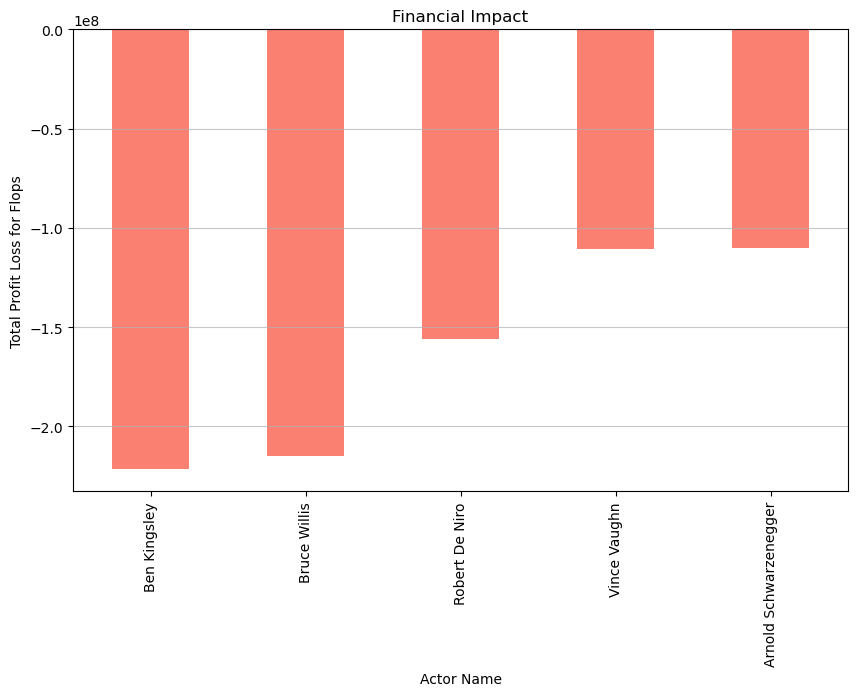

In [274]:
#create a side by side visualization (line graph)? of money lost by the "top 5" cast and crew

actor_loss = bad_movies.groupby('actor_name')['profit'].sum().sort_values()

plt.figure(figsize=(10, 6))
actor_loss.plot(kind='bar', color='salmon')

plt.title('Financial Impact')
plt.ylabel('Total Profit Loss for Flops')
plt.xlabel('Actor Name')
plt.grid(axis='y', alpha=0.7)

plt.show()



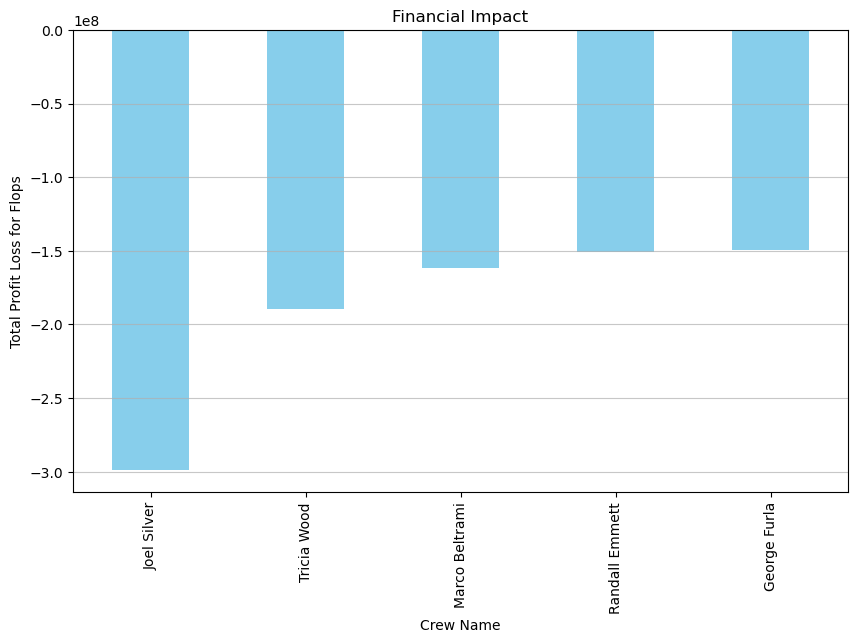

In [275]:
crew_loss = bad_movies_crew.groupby('crew_name')['profit'].sum().sort_values()

plt.figure(figsize=(10, 6))
crew_loss.plot(kind='bar', color='skyblue')

plt.title('Financial Impact')
plt.ylabel('Total Profit Loss for Flops')
plt.xlabel('Crew Name')
plt.grid(axis='y', alpha=0.7)

plt.show()